In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)

In [ ]:
# if needed, uncomment and install xgboost
# %pip install xgboost

In [2]:
from xgboost import XGBClassifier

In [3]:
df = pd.read_csv("../data/cme_dataset.csv", parse_dates=["cme_time"])

print("Dataset shape:", df.shape)
print("Date range:", df["cme_time"].min(), "to", df["cme_time"].max())
print("\nTarget balance:")
print(df["storm"].value_counts())
print("Storm percent:", round(df["storm"].mean() * 100, 2), "%")

df.head()

Dataset shape: (4734, 30)
Date range: 2017-02-10 13:48:00 to 2024-12-29 18:24:00

Target balance:
storm
0    3655
1    1079
Name: count, dtype: int64
Storm percent: 22.79 %


,cme_time,cme_speed_kms,cme_half_angle_deg,cme_latitude,cme_longitude,cme_type_num,cme_id,flare_class,flare_class_num,flare_log_peak_flux,...,wind_density_mean,wind_pressure_mean,wind_efield_mean,wind_temp_mean,ctx_f107,ctx_sunspots,kp_max_post,storm,storm_attributed,storm_attributed_v2
0,2017-02-10 13:48:00,594.0,10.0,18.0,148.0,2.0,0,NaN,NaN,NaN,...,5.500000,2.005278,0.243889,70931.944444,72.027778,22.555556,2.3,0,0,0
1,2017-02-11 06:00:00,456.0,18.0,-1.0,93.0,1.0,1,NaN,NaN,NaN,...,4.745946,1.616486,0.265946,56423.216216,72.972973,23.486486,2.3,0,0,0
2,2017-02-15 03:09:00,405.0,12.0,16.0,-173.0,1.0,2,NaN,NaN,NaN,...,12.597222,2.053611,0.010000,18074.472222,72.833333,19.555556,4.3,0,0,0
3,2017-02-18 02:30:00,239.0,17.0,26.0,-110.0,1.0,3,B,1.0,-6.885685,...,6.983333,3.387500,0.509722,149947.583333,73.675000,13.583333,3.7,0,0,0
4,2017-02-18 07:24:00,492.0,27.0,4.0,88.0,1.0,4,NaN,NaN,NaN,...,6.444444,3.187778,0.266111,137876.500000,73.966667,13.444444,3.7,0,0,0


In [4]:
FEATURE_COLS = [
    "cme_speed_kms",
    "cme_half_angle_deg",
    "cme_latitude",
    "cme_longitude",
    "cme_type_num",
    "flare_class_num",
    "flare_log_peak_flux",
    "flare_duration_min",
    "flare_end_time_imputed",
    "has_flare",
    "wind_bz_mean",
    "wind_bz_min",
    "wind_bz_south_frac",
    "wind_bz_strong_south_frac",
    "wind_imf_mean",
    "wind_speed_mean",
    "wind_speed_max",
    "wind_density_mean",
    "wind_pressure_mean",
    "wind_efield_mean",
    "wind_temp_mean",
    "ctx_f107",
    "ctx_sunspots",
]

TARGET_COL = "storm"

X = df[FEATURE_COLS]
y = df[TARGET_COL]

print("Number of features:", len(FEATURE_COLS))
print("X shape:", X.shape)
print("y shape:", y.shape)

Number of features: 23
X shape: (4734, 23)
y shape: (4734,)


In [5]:
test_filter = df["cme_time"] >= "2023-01-01"
train_filter = df["cme_time"] < "2023-01-01"

X_train = df.loc[train_filter, FEATURE_COLS]
y_train = df.loc[train_filter, TARGET_COL]

X_test = df.loc[test_filter, FEATURE_COLS]
y_test = df.loc[test_filter, TARGET_COL]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain target balance:")
print(y_train.value_counts())
print("Train storm percent:", round(y_train.mean() * 100, 2), "%")

print("\nTest target balance:")
print(y_test.value_counts())
print("Test storm percent:", round(y_test.mean() * 100, 2), "%")

Train shape: (1988, 23)
Test shape: (2746, 23)

Train target balance:
storm
0    1624
1     364
Name: count, dtype: int64
Train storm percent: 18.31 %

Test target balance:
storm
0    2031
1     715
Name: count, dtype: int64
Test storm percent: 26.04 %


In [ ]:
# XGBoost baseline model
# number of negative training examples / number of positive training examples
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()
scale_pos_weight = negative_count / positive_count

print("scale_pos_weight:", round(scale_pos_weight, 2))

scale_pos_weight: 4.46


In [7]:
xgb_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    )),
])

xgb_pipe.fit(X_train, y_train)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('clf',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=0.8, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='logloss',
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=3, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=-1,
                               num_parallel_tree=None, ...))])

In [8]:
y_pred = xgb_pipe.predict(X_test)
y_pred_prob = xgb_pipe.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_pred_prob)
pr_auc = average_precision_score(y_test, y_pred_prob)

print(f"ROC-AUC : {roc_auc:.3f}")
print(f"PR-AUC  : {pr_auc:.3f}  (no-skill baseline = {y_test.mean():.3f})")
print()
print(classification_report(y_test, y_pred, target_names=["No storm", "Storm"]))

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

ROC-AUC : 0.428
PR-AUC  : 0.220  (no-skill baseline = 0.260)

              precision    recall  f1-score   support

    No storm       0.72      0.85      0.78      2031
       Storm       0.15      0.07      0.10       715

    accuracy                           0.65      2746
   macro avg       0.44      0.46      0.44      2746
weighted avg       0.57      0.65      0.60      2746

Confusion matrix:
[[1733  298]
 [ 663   52]]


More complex tree-based models did not automatically improve performance on this time-based split. Logistic Regression performed better as a baseline in terms of ROC-AUC and PR-AUC, while XGBoost and Random Forest struggled to generalize to the later test period.

In [9]:
# threshold table
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

thresholds = [0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50]

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_pred_prob >= threshold).astype(int)
    
    threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, y_pred_threshold),
        "precision_storm": precision_score(y_test, y_pred_threshold, zero_division=0),
        "recall_storm": recall_score(y_test, y_pred_threshold, zero_division=0),
        "f1_storm": f1_score(y_test, y_pred_threshold, zero_division=0),
        "predicted_storm_count": y_pred_threshold.sum()
    })

threshold_results_df = pd.DataFrame(threshold_results)
threshold_results_df

,threshold,accuracy,precision_storm,recall_storm,f1_storm,predicted_storm_count
0,0.15,0.513110,0.204934,0.302098,0.244206,1054
1,0.20,0.538602,0.196035,0.248951,0.219347,908
2,0.25,0.558267,0.187970,0.209790,0.198282,798
3,0.30,0.583758,0.193410,0.188811,0.191083,698
4,0.35,0.602695,0.184564,0.153846,0.167811,596
5,0.40,0.618354,0.166333,0.116084,0.136738,499
6,0.50,0.650036,0.148571,0.072727,0.097653,350


### Threshold Comparison

Using the default 0.50 threshold, the XGBoost model predicted relatively few storm events and had low storm recall. Lowering the threshold increased recall, but precision remained low, meaning the model produced more false positives while still missing many true storm events.

The best storm F1-score among the tested thresholds occurred at 0.15, but performance was still weak overall. This suggests that threshold adjustment alone is not enough to solve the model's poor generalization on the later test period.

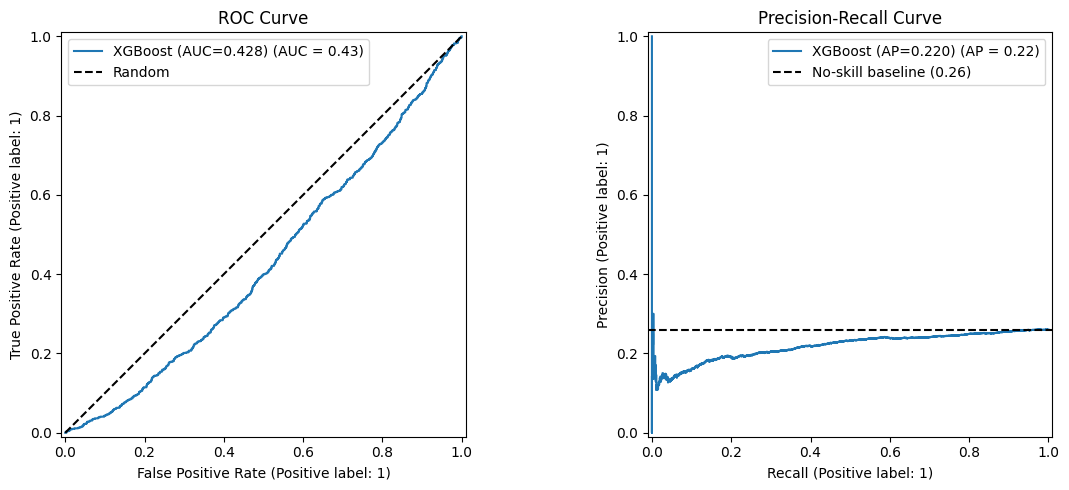

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_predictions(
    y_test,
    y_pred_prob,
    name=f"XGBoost (AUC={roc_auc:.3f})",
    ax=axes[0],
)
axes[0].plot([0, 1], [0, 1], "k--", label="Random")
axes[0].set_title("ROC Curve")
axes[0].legend()

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_pred_prob,
    name=f"XGBoost (AP={pr_auc:.3f})",
    ax=axes[1],
)
axes[1].axhline(
    y_test.mean(),
    color="k",
    linestyle="--",
    label=f"No-skill baseline ({y_test.mean():.2f})"
)
axes[1].set_title("Precision-Recall Curve")
axes[1].legend()

plt.tight_layout()
plt.show()

### ROC and Precision-Recall Curve Interpretation

The XGBoost baseline performed weakly on the time-based test set. The ROC-AUC was 0.428, which is below the random baseline of 0.5, indicating that the model did not rank storm-causing CMEs above non-storm CMEs well. The PR-AUC was 0.220, which was also below the no-skill baseline of 0.260. Since the storm class is the positive class, this suggests that the model struggled to identify storm events in the later test period.

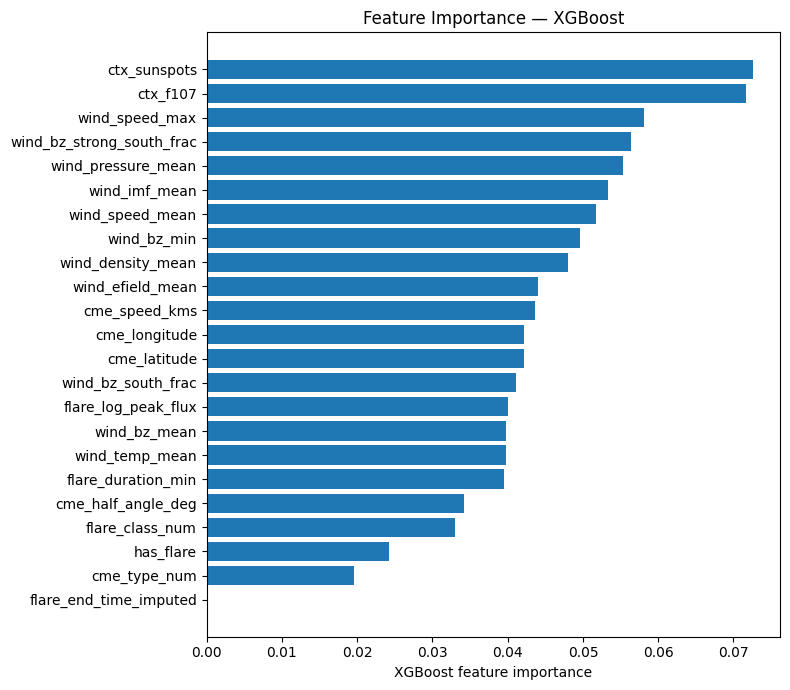


Top features:
ctx_sunspots                 0.072560
ctx_f107                     0.071648
wind_speed_max               0.058068
wind_bz_strong_south_frac    0.056326
wind_pressure_mean           0.055295
wind_imf_mean                0.053311
wind_speed_mean              0.051790
wind_bz_min                  0.049609
wind_density_mean            0.048079
wind_efield_mean             0.044079


In [11]:
importances = pd.Series(
    xgb_pipe.named_steps["clf"].feature_importances_,
    index=FEATURE_COLS
).sort_values()

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(importances.index, importances.values)
ax.set_xlabel("XGBoost feature importance")
ax.set_title("Feature Importance — XGBoost")
plt.tight_layout()
plt.show()

print("\nTop features:")
print(importances.tail(10).iloc[::-1].to_string())

### Feature Importance Interpretation

The XGBoost model relied most heavily on solar context variables (`ctx_sunspots`, `ctx_f107`) and solar wind features such as maximum wind speed, strong southward Bz fraction, solar wind pressure, IMF strength, Bz minimum, density, and electric field. These features are physically relevant because they describe both broader solar activity conditions and near-Earth solar wind behavior.

However, XGBoost feature importance does not show whether higher feature values increase or decrease storm probability. It only indicates how much each feature contributed to the model's tree-based splits. Since the overall ROC-AUC and PR-AUC were weak, these importance values should be interpreted cautiously as part of an initial baseline rather than as final scientific conclusions.

## Initial XGBoost Baseline Summary

This notebook trained an initial XGBoost baseline using the same merged CME dataset, feature set, and time-based train/test split used for the other baseline models. The model used `scale_pos_weight` to account for the imbalance between storm and non-storm examples in the training set.

On the 2023 onward test set, XGBoost achieved a ROC-AUC of 0.428 and a PR-AUC of 0.220, which was below the no-skill PR baseline of 0.260. At the default 0.50 threshold, the model had low storm recall and missed most storm events. Lowering the classification threshold improved recall somewhat, but precision remained low and overall performance was still weak.

Overall, this initial XGBoost baseline did not outperform the simpler logistic regression baseline on this time-based split. Future work could include hyperparameter tuning, alternative time-based validation splits, better event attribution logic, or revised target definitions.

* **Precision** — Of all the CMEs the model predicted would cause a storm, what fraction actually did? High precision = few false alarms.

* **Recall** — Of all the CMEs that actually caused a storm, what fraction did the model catch? High recall = few missed storms.

* **F1 score** — The harmonic mean of precision and recall. A single number that balances both. Useful when you care about both false alarms and missed storms.

* **Support** — The count of actual examples in each class in the test set. It tells you how many “No storm” and “Storm” rows the metrics are based on.

* **ROC-AUC** — Measures how well the model ranks storm-causing CMEs above non-storm CMEs across all possible thresholds. 0.5 = random, 1.0 = perfect. It does not depend on one fixed classification threshold.

* **PR-AUC / Average Precision** — Measures performance across the precision-recall curve. This is more informative than ROC-AUC when the classes are imbalanced because it focuses on how well the model finds the positive class, which is storm events. The no-skill baseline is the storm rate in the test set.

* **ROC curve** — Plots true positive rate, or recall, against false positive rate at every possible threshold. The further the curve bends toward the top-left corner, the better.

* **Precision-Recall curve** — Plots precision against recall at every threshold. This is a better diagnostic for imbalanced data because it focuses on the tradeoff between catching storms and avoiding false alarms. The flat dashed line is the no-skill baseline.

* **XGBoost feature importance** — XGBoost does not learn one positive or negative coefficient per feature like logistic regression. Instead, feature importance shows how much each feature contributed to the model’s tree-based splits. A higher importance value means the model used that feature more for prediction, but it does not tell us whether higher values of that feature increase or decrease storm probability.
